# Chapter 10.2 — Evaluating a Classifier

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Part 10.1 grew a decision tree from fourteen golf days and read it as five rules; it scored 100% on the days it was grown from. This part asks how good the tree really is. It applies the Chapter 9 toolkit — predicted against actual, the four boxes of the confusion matrix, accuracy, precision, recall and F₁ — to that tree, on days it has **not** seen, and then repeats the test many times with cross-validation. The same evaluation is then applied to a real dataset — 569 breast-cancer tumors — with scikit-learn, and the homework asks questions of that dataset.

**In this chapter:** Predicted against actual · Held-out days · The four boxes · Accuracy, precision, recall, F₁ · Cross-validation · The breast-cancer tumors · scikit-learn · Homework



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Compare predicted with actual** — lay a model's answers beside what really happened, and place every case in one of four boxes.
> - **Read the four metrics** — accuracy, precision, recall and F₁ as ratios of the boxes, and which mistake each one sees.
> - **Test on unseen data** — say why the score on the training rows is only how well the model fits, and measure how well it predicts.
> - **Check for consistency** — run the test many times with cross-validation and read whether the scores agree.



**Contents**

- **10.2.1 · The tree from Part 10.1** — the model under test, rebuilt in one cell
- **10.2.2 · The confusion matrix** — recap from Chapter 9: the four boxes and the four metrics
- **10.2.3 · Predicted against actual, day by day** — held-out predictions, and the boxes counted
- **10.2.4 · The tree's four metrics** — how well it fits against how well it predicts
- **10.2.5 · Cross-validation** — testing the model many times
- **10.2.6 · A real dataset — the breast-cancer tumors** — the same evaluation with scikit-learn
- **10.2.7 · Glossary** — the terms of this part
- **10.2.8 · Homework** — the graded work, on the tumors



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The graded work is Section 10.2.8.

> **Continuing from Chapter 9 and Part 10.1.** Chapter 9 taught the confusion matrix, its four metrics and cross-validation in full (Sections 9.3.4 and 9.3.5), on a screening example of 1,000 people. They are recapped here in one place each, with Chapter 9's own numbers, and then applied to this chapter's model. Part 10.1 grew the tree; its functions are rebuilt in one cell in Section 10.2.1.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section 10.2.6 adds scikit-learn when the real dataset is loaded.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.2.1 · The tree from Part 10.1

*the model under test*

> **Recap from Part 10.1.** Fourteen golf days, each with four features — outlook, temperature, humidity, wind — and the answer: whether golf was played. Nine Yes, five No. The tree was grown by trying every feature as a question and keeping the one that settled the most days, with the purest groups, then running the same search again inside each mixed branch. Two questions deep, five leaves, every leaf pure — and 100% on the fourteen days it was grown from. That is how well it fits. This part measures how well it predicts.

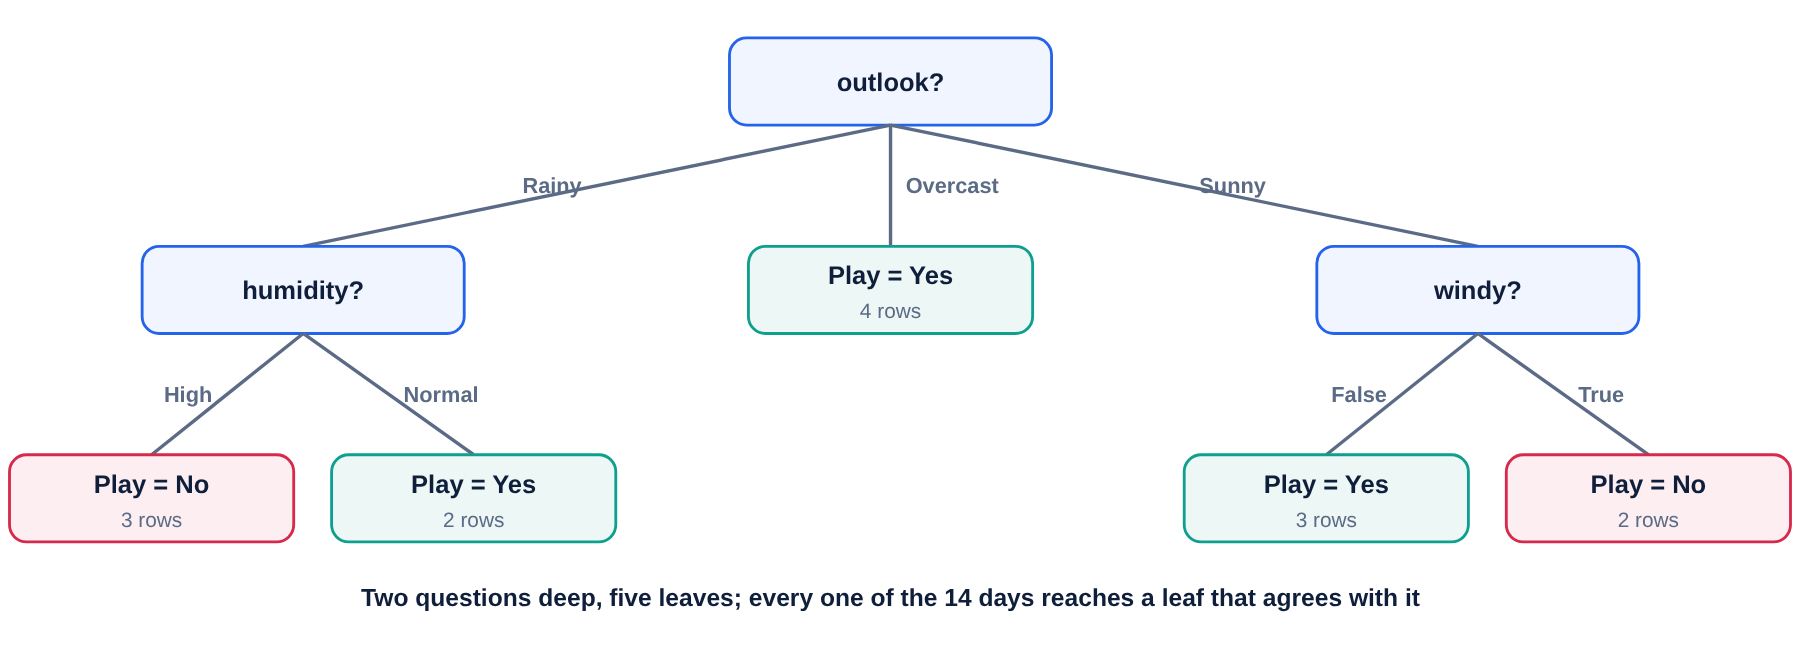

*The tree of Part 10.1, the model this part evaluates.*



#### The steps

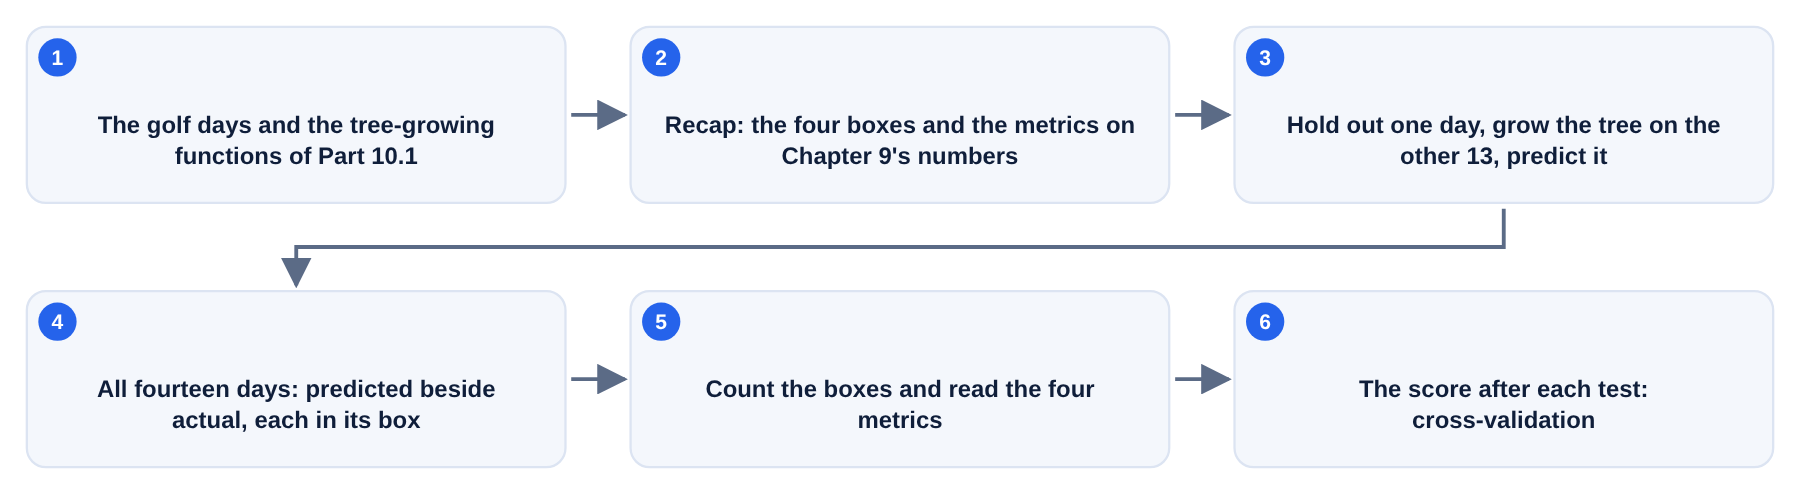

*The code walk of Sections 10.2.1 to 10.2.5.*



#### The golf days

The fourteen days of Part 10.1, in the same table, so this notebook stands on its own.



In [2]:
golf = pd.DataFrame({
    "outlook":  ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast",
                 "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "temp":     ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                 "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "windy":    ["No", "Yes", "No", "No", "No", "Yes", "Yes",
                 "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "play":     ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                 "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})
golf.index = range(1, 15)
FEATURES = ["outlook", "temp", "humidity", "windy"]
golf

,outlook,temp,humidity,windy,play
1,Rainy,Hot,High,No,No
2,Rainy,Hot,High,Yes,No
3,Overcast,Hot,High,No,Yes
4,Sunny,Mild,High,No,Yes
5,Sunny,Cool,Normal,No,Yes
6,Sunny,Cool,Normal,Yes,No
7,Overcast,Cool,Normal,Yes,Yes
8,Rainy,Mild,High,No,No
9,Rainy,Cool,Normal,No,Yes
10,Sunny,Mild,Normal,No,Yes


#### The functions of Part 10.1

The four functions of Part 10.1: `split_score` scores a question by the days its groups settle and the pure groups it makes, `best_feature` picks the winner, `grow_tree` runs the search in every branch, and `predict` walks a day from the root to a leaf. The cell ends by growing the tree and checking it on its own days.



> **Interpretation.** 100% — the number Part 10.1 ended on. Every question in this part is about whether that number means anything.



In [3]:
def split_score(df, feature, target="play"):
    counts = pd.crosstab(df[feature], df[target])
    return int(counts.max(axis=1).sum()), int((counts.gt(0).sum(axis=1) == 1).sum())   # (settled, pure)

def best_feature(df, features, target="play"):
    return max(features, key=lambda f: split_score(df, f, target))

def grow_tree(df, features, target="play"):
    labels = df[target]
    if labels.nunique() == 1:
        return {"leaf": labels.iloc[0], "n": len(df)}
    if not features:
        return {"leaf": labels.value_counts().sort_index().idxmax(), "n": len(df)}
    question = best_feature(df, features, target)
    rest = [f for f in features if f != question]
    return {"question": question, "n": len(df),
            "branches": {value: grow_tree(group, rest, target) for value, group in df.groupby(question)}}

def predict(node, row):
    while "leaf" not in node:
        value = row[node["question"]]
        if value not in node["branches"]:
            return None
        node = node["branches"][value]
    return node["leaf"]

tree = grow_tree(golf, FEATURES)
on_own_days = golf.apply(lambda row: predict(tree, row), axis=1) == golf["play"]
print(f"the tree grown on all 14 days is right on {on_own_days.sum()} of 14 of them: {on_own_days.mean():.0%}")

the tree grown on all 14 days is right on 14 of 14 of them: 100%


## 10.2.2 · The confusion matrix

*recap from Chapter 9*

Evaluating a classifier starts with one comparison per case: what the model predicted beside what actually happened. Every case then lands in exactly one of four boxes, and the four counts are the **confusion matrix**. In a binary problem one class is the positive class — here Yes, the days golf was played — and the boxes are named from its point of view.

|  | actually Yes | actually No |
|---|---|---|
| **predicted Yes** | **TP** — true positive, a correct catch | **FP** — false positive, a Type I error |
| **predicted No** | **FN** — false negative, a Type II error | **TN** — true negative, a correct pass |

> **Recap from Chapter 9.** Section 9.3.5 worked this on 1,000 screened people, 60 of them ill, 50 flagged, 40 of those correctly: TP 40, FP 10, FN 20, TN 930. Accuracy $970/1000 = 97.0\%$ — and 94% for a model that flags nobody. Precision $40/50 = 80.0\%$: of those flagged, the share really ill. Recall $40/60 = 66.7\%$: of the ill, the share caught. $F_1 = 72.7\%$. Accuracy is nearly blind to a rare class; precision and recall see the two mistakes separately.

$$\text{Accuracy} = \frac{TP + TN}{n} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2\,PR}{P + R}$$

*Every metric, as a ratio of the four boxes.* $n$ is every case in the table. Precision divides by the row the model chose, recall by the column the truth chose; $F_1$ balances the two — it is high only when both are.



#### The four boxes of the Chapter 9 example

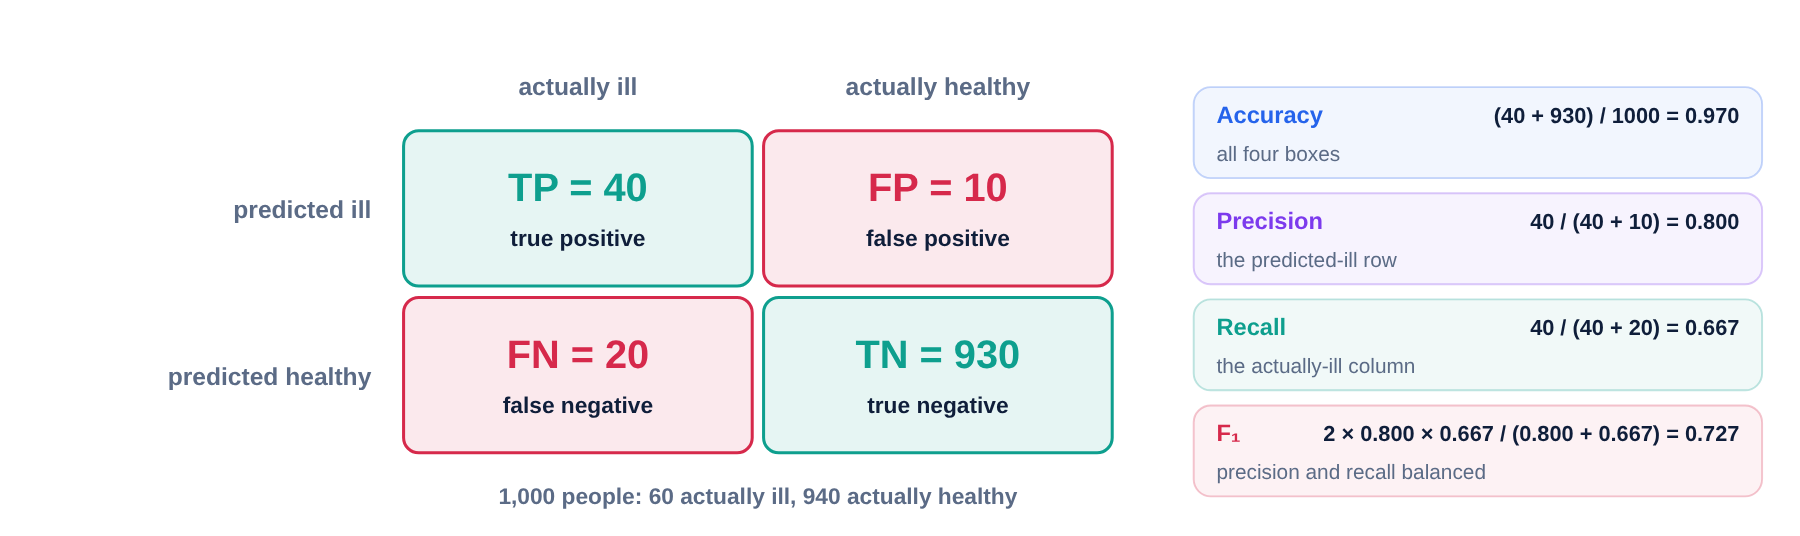

*The Chapter 9 screening example. The large TN box makes accuracy high; precision and recall read the two mistakes separately.*



#### The four metrics

The four formulas become one function that takes the four counts and returns the four metrics as a small table. It is checked on Chapter 9's numbers first, so that when it is applied to the tree there is no doubt about what it computes.

$$\text{Accuracy} = \frac{TP + TN}{n} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2\,PR}{P + R}$$



> **Interpretation.** 0.970, 0.800, 0.667, 0.727 — the Chapter 9 values. The function is now ready for the tree.



In [4]:
def four_metrics(tp, fp, fn, tn):
    """Accuracy, precision, recall and F1 from the four boxes of a confusion matrix."""
    n = tp + fp + fn + tn
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return pd.Series({
        "accuracy":  (tp + tn) / n,
        "precision": precision,
        "recall":    recall,
        "F1":        2 * precision * recall / (precision + recall),
    }).round(3)

four_metrics(tp=40, fp=10, fn=20, tn=930)

accuracy     0.970
precision    0.800
recall       0.667
F1           0.727
dtype: float64

## 10.2.3 · Predicted against actual, day by day

*held-out predictions*

The tree is right on every day it was grown from, because it kept asking questions until every group was pure. To learn how it does on a day it has **not** seen, a day is held back: the tree is grown on the other thirteen days and then asked about the one it never saw. Doing this for each of the fourteen days gives fourteen honest predictions, one per day, and each can be written beside what really happened and placed in its box.

> **Why one day at a time.** This is the train/test split of Chapter 9 (Section 9.3.2), in the only form fourteen rows allow: a training set of thirteen and a test set of one, repeated fourteen times so that every day is tested once. With more rows the split is made once, or the rows are cut into a few folds: Section 10.2.6 makes one split of a real dataset, and Exercise 4 of the homework cuts the same dataset into five folds.



#### One held-out day

Day 4 is a sunny, mild, humid day with no wind, and golf was played. `golf.drop(index=4)` removes it; the tree is grown on the remaining thirteen days and asked about day 4. The cell prints the answer beside the truth.



> **Interpretation.** Predicted No, actually Yes: a false negative. Without day 4, humidity settles 10 of the thirteen days against outlook's 9, so the tree grown on thirteen days asks about humidity first, not outlook. Day 4 (humidity High, outlook Sunny) then reaches a leaf built from the one remaining Sunny day with high humidity, day 14, which was not played — so the tree answers No.



In [5]:
held_out = golf.loc[4]
tree_without_4 = grow_tree(golf.drop(index=4), FEATURES)
print("day 4:", dict(held_out))
print("predicted:", predict(tree_without_4, held_out), "   actual:", held_out["play"])

day 4: {'outlook': 'Sunny', 'temp': 'Mild', 'humidity': 'High', 'windy': 'No', 'play': 'Yes'}
predicted: No    actual: Yes


#### All fourteen days

The same three lines run once per day in a loop; a small function names the box each (actual, predicted) pair falls in, with Yes as the positive class.



> **Interpretation.** Fourteen rows, one per day, each in exactly one box.
>
> - **Eleven rows agree**: 7 TP (played, predicted Yes) and 4 TN (not played, predicted No).
> - **Days 4 and 11** were played but predicted No — the two false negatives.
> - **Day 8** was not played but predicted Yes — the one false positive.



In [6]:
def box(actual, predicted, positive="Yes"):
    """Which of the four boxes a (actual, predicted) pair lands in."""
    if predicted == positive:
        return "TP" if actual == positive else "FP"
    return "FN" if actual == positive else "TN"

rows = []
for day in golf.index:
    tree_without = grow_tree(golf.drop(index=day), FEATURES)          # grown without this day
    predicted = predict(tree_without, golf.loc[day])                  # asked about this day
    rows.append({"actual": golf.loc[day, "play"], "predicted": predicted,
                 "box": box(golf.loc[day, "play"], predicted)})
comparison = pd.DataFrame(rows, index=golf.index)
comparison

,actual,predicted,box
1,No,No,TN
2,No,No,TN
3,Yes,Yes,TP
4,Yes,No,FN
5,Yes,Yes,TP
6,No,No,TN
7,Yes,Yes,TP
8,No,Yes,FP
9,Yes,Yes,TP
10,Yes,Yes,TP


#### Counting the four boxes

The boxes are simply the rows counted: `value_counts()` on the box column, reindexed so all four appear in a fixed order even when a count is zero. The four counts add to 14.



> **Interpretation.** TP 7, FP 1, FN 2, TN 4. Of the nine days golf was played, the tree caught seven and missed two; of the five days it was not, the tree passed four and raised one false alarm.



In [7]:
counts = comparison["box"].value_counts().reindex(["TP", "FP", "FN", "TN"], fill_value=0)
print("total:", counts.sum())
counts

total: 14


box
TP    7
FP    1
FN    2
TN    4
Name: count, dtype: int64

#### The tree's four boxes

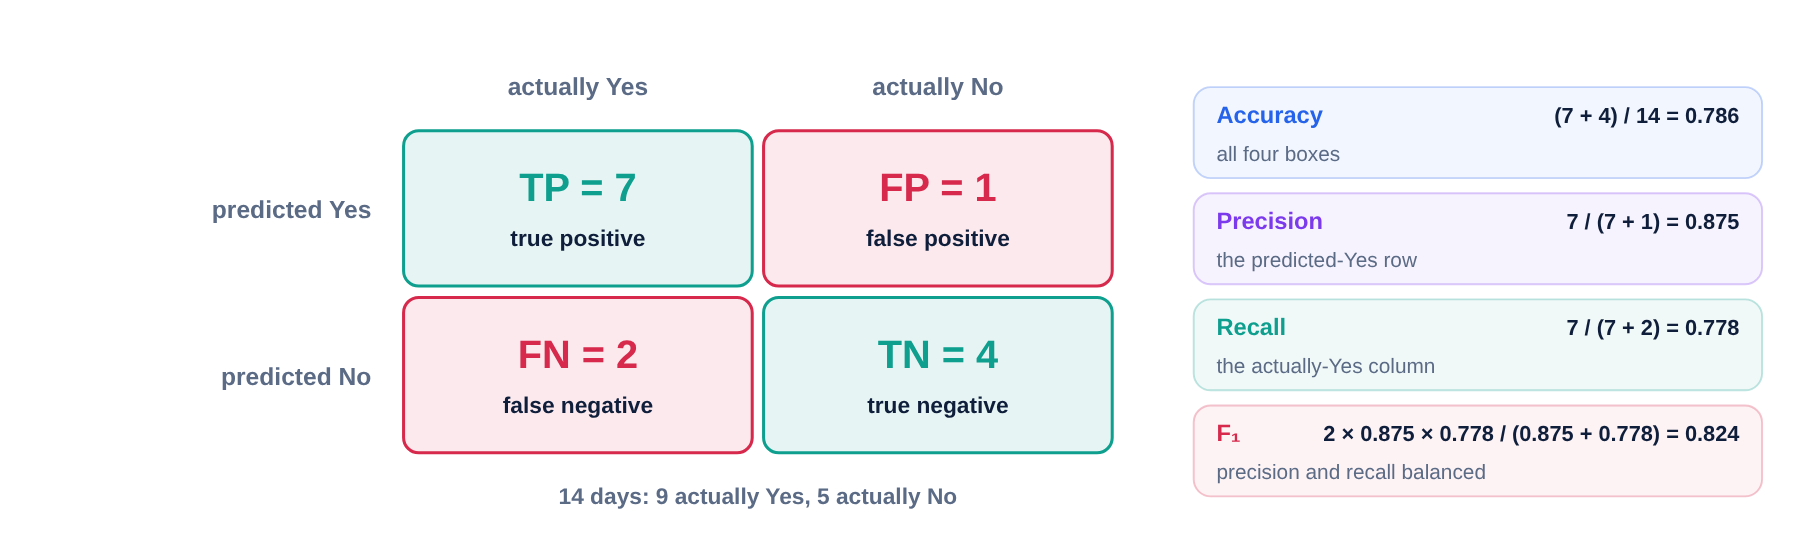

*The fourteen held-out comparisons counted into the four boxes, with Yes as the positive class, and the four metrics read off them.*



## 10.2.4 · The tree's four metrics

*how well it fits against how well it predicts*

With the four counts in hand, the metrics of Section 10.2.2 are read off them. Each is a ratio of boxes, and each answers a different question about the tree.



#### The metrics of the held-out tree

The `four_metrics` function of Section 10.2.2, applied to the counts just made.

$$\text{Accuracy} = \frac{7 + 4}{14} \qquad \text{Precision} = \frac{7}{7 + 1} \qquad \text{Recall} = \frac{7}{7 + 2} \qquad F_1 = \frac{2 \times 0.875 \times 0.778}{0.875 + 0.778}$$



> **Interpretation.** Read the numbers:
>
> - **Accuracy 0.786** — right on 11 of 14 held-out days. Against the 100% on its own days, this is how well the tree predicts; the 100% was only how well it fits.
> - **Precision 0.875** — of the 8 days the tree said Yes, 7 were really played.
> - **Recall 0.778** — of the 9 days golf was played, the tree caught 7.
> - **F₁ 0.824** — precision and recall balanced in one number.



In [8]:
four_metrics(tp=counts["TP"], fp=counts["FP"], fn=counts["FN"], tn=counts["TN"])

accuracy     0.786
precision    0.875
recall       0.778
F1           0.824
dtype: float64

#### Held-out numbers, not training numbers

> **Watch out.** On its own 14 days the tree scored 100%. Asked about a day it had not seen, it is right 11 times in 14: it misses two days golf was played and predicts golf once when there was none. Only the held-out numbers say how the tree will do on tomorrow's weather, and only they are worth reporting.



## 10.2.5 · Cross-validation

*testing the model many times*

One test on one set of days can be lucky or unlucky. **Cross-validation** repeats the test many times, each time on rows the model has not seen, and looks at whether the scores agree. Here the fourteen held-out predictions of Section 10.2.3 are fourteen tests: each day in turn was hidden, the tree was grown on the other thirteen, and its answer for the hidden day was right or wrong. Watching the score settle as the tests accumulate shows what one test alone cannot.

> **Recap from Chapter 9.** Section 9.3.4 introduced cross-validation as $k$-fold: cut the rows into $k$ folds, hold out each fold in turn, and average the $k$ scores. Holding out one row at a time, as here, is the case $k = n$; with hundreds of rows five folds are the usual choice, and Section 10.2.8 uses them.



#### The score after each test

A test is right when the held-out prediction equals the actual answer. `cumsum()` adds the rights up test by test, and dividing by the number of tests so far gives the score after each one — a running accuracy that starts with a single test and ends with all fourteen. The chart in the next cell draws this accuracy so far against the number of held-out tests run.



> **Interpretation.** The running score after each held-out day.
>
> - **Tests 1 to 3 — 1.000.** A single test can only say 0% or 100%; three right in a row keep it at 1.
> - **Test 4 — 0.750.** Day 4 is missed and one wrong in four pulls the score down at once.
> - **Tests 5 to 13 — between 0.75 and 0.86**, moving less with every test added.
> - **Test 14 — 0.786**, the 11 of 14 that the confusion matrix counted.



In [9]:
right = (comparison["actual"] == comparison["predicted"]).astype(int)
running = pd.DataFrame({
    "right": right,
    "tests so far": np.arange(1, 15),
    "score so far": (right.cumsum() / np.arange(1, 15)).round(3),
}, index=golf.index)
running

,right,tests so far,score so far
1,1,1,1.000
2,1,2,1.000
3,1,3,1.000
4,0,4,0.750
5,1,5,0.800
6,1,6,0.833
7,1,7,0.857
8,0,8,0.750
9,1,9,0.778
10,1,10,0.800


#### The score settling

The running score as a line, with the training score of 100% drawn for comparison. Each point is one more held-out test.



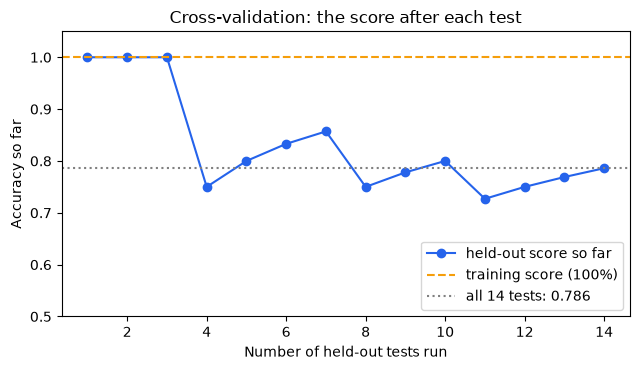

In [10]:
plt.figure(figsize=(6.5, 3.8))
plt.plot(running["tests so far"], running["score so far"], marker="o", color="#2563EB", label="held-out score so far")
plt.axhline(1.0, color="#F59E0B", linestyle="--", label="training score (100%)")
plt.axhline(11 / 14, color="gray", linestyle=":", label="all 14 tests: 0.786")
plt.ylim(0.5, 1.05)
plt.xlabel("Number of held-out tests run")
plt.ylabel("Accuracy so far")
plt.title("Cross-validation: the score after each test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### What the chart shows

> **Interpretation.** What the chart shows:
>
> - **The blue line** — the held-out score after each test — swings widely at first and settles as tests accumulate. Any single test would have said 0% or 100%.
> - **The dashed line at 100%** is the training score. The gap between it and the settled 0.786 is the difference between fitting the days and predicting them.
> - **Only the settled score is worth reporting.** Cross-validation exists to reach it: many tests, each on unseen rows, averaged.



#### Where Sections 10.2.1 to 10.2.5 leave us

> **Key idea.** The tree of Part 10.1 has been judged honestly: 11 of 14 held-out days, precision 0.875, recall 0.778, and a score that settles at 0.786 as the tests accumulate — against the 100% that fitting alone produced. The rest of this part applies the same evaluation to a real dataset, with a library, so the homework can ask its questions of it.



## 10.2.6 · A real dataset — the breast-cancer tumors

*the same evaluation with scikit-learn*

The dataset is the Wisconsin breast-cancer data, bundled with scikit-learn: 569 tumors, each described by 30 measurements taken from a digitized image of a biopsy — the size, texture and shape of the cell nuclei — and each labeled by what the biopsy found: **malignant** (cancer) or **benign** (not cancer). Two classes, so this is a binary problem, and the positive class — the one being looked for — is malignant.

> **The question.** From the 30 measurements of a tumor, how well can a decision tree tell malignant from benign — and which mistake does it make more often: calling a benign tumor malignant, or a malignant one benign?

> **The split.** With 569 rows the train/test split is made once, as in Chapter 9: 70% of the tumors train the tree and 30% are held back to test it. `train_test_split` does the splitting; `stratify=` keeps the share of malignant tumors the same in both parts, and the seed 888102 makes every student's split identical. The tree is grown three questions deep, so that it does not simply memorize the training rows.



#### The steps

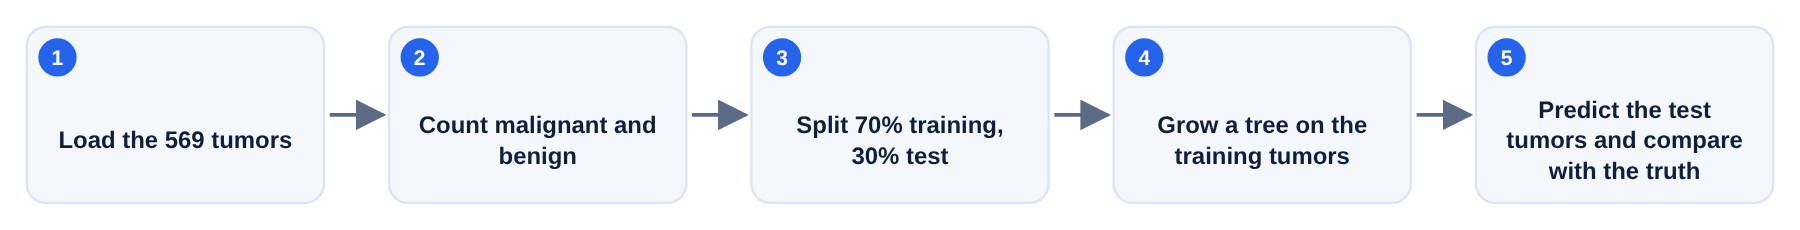

*The tumor walk. The homework in Section 10.2.8 counts the boxes, reads the metrics and cross-validates.*



#### Loading the tumors

`load_breast_cancer(as_frame=True)` returns the 30 measurements as a table and the diagnosis as a number, 0 for malignant and 1 for benign. The cell replaces the numbers with the two words, so that every later output reads as a diagnosis rather than a code, and shows the first rows of a few columns.



> **Interpretation.** 569 rows and 31 columns: 30 measurements and the diagnosis. The measurements are sizes and shapes of the cell nuclei — a radius in pixels, a texture, how concave the outline is — each given as a mean, a standard error and a worst value across the nuclei in the image.



In [11]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
tumors = cancer.data.copy()
tumors["diagnosis"] = np.where(cancer.target == 0, "malignant", "benign")    # 0 = malignant in the file
print("shape:", tumors.shape)
tumors[["mean radius", "mean texture", "mean concavity", "worst radius", "diagnosis"]].head()

shape: (569, 31)


,mean radius,mean texture,mean concavity,worst radius,diagnosis
0,17.99,10.38,0.3001,25.38,malignant
1,20.57,17.77,0.0869,24.99,malignant
2,19.69,21.25,0.1974,23.57,malignant
3,11.42,20.38,0.2414,14.91,malignant
4,20.29,14.34,0.1980,22.54,malignant


#### Malignant and benign

The count of each class, before anything is predicted. It says how mixed the whole table is and what a model that always answered benign would score.



> **Interpretation.** 212 malignant and 357 benign. A model that called every tumor benign would be 63% accurate and would miss every cancer — the reason accuracy alone is not enough here, and precision and recall are needed.



In [12]:
tumors["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

#### The split

`train_test_split` shuffles the rows with the seed and cuts them 70/30; `stratify=y` keeps the malignant share the same in both parts. Four objects come back: the training features and labels, and the test features and labels. The cell prints the sizes and the malignant count in each part.



> **Interpretation.** 398 tumors to learn from and 171 held back, with the same share of malignant tumors in each. The 171 test tumors have their diagnoses hidden from the tree until the comparison.



In [13]:
from sklearn.model_selection import train_test_split

X = tumors.drop(columns="diagnosis")
y = tumors["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
print("training tumors:", len(X_train), "  of which malignant:", (y_train == "malignant").sum())
print("test tumors:    ", len(X_test), "  of which malignant:", (y_test == "malignant").sum())

training tumors: 398   of which malignant: 148
test tumors:     171   of which malignant: 64


#### Growing the tree on the training tumors

`DecisionTreeClassifier(max_depth=3)` grows a tree three questions deep on the training rows only; `export_text` prints it, and `.score(X_train, y_train)` is its training accuracy — how well it fits the rows it has seen.



> **Interpretation.** The root asks how concave the outline of the nuclei is (mean concave points): a smoother outline goes left, toward benign, and a more indented one right, where the size of the nuclei (worst area) decides. Three questions deep, eight leaves. The training accuracy is high, as it always is on the rows a tree was grown from; it is not the number that matters.



In [14]:
from sklearn.tree import DecisionTreeClassifier, export_text

model = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
print(export_text(model, feature_names=list(X.columns), class_names=list(model.classes_)))
print(f"training accuracy: {model.score(X_train, y_train):.1%}")

|--- mean concave points <= 0.05
|   |--- worst area <= 929.80
|   |   |--- worst smoothness <= 0.18
|   |   |   |--- class: benign
|   |   |--- worst smoothness >  0.18
|   |   |   |--- class: benign
|   |--- worst area >  929.80
|   |   |--- mean texture <= 18.68
|   |   |   |--- class: benign
|   |   |--- mean texture >  18.68
|   |   |   |--- class: malignant
|--- mean concave points >  0.05
|   |--- worst area <= 785.80
|   |   |--- worst symmetry <= 0.33
|   |   |   |--- class: benign
|   |   |--- worst symmetry >  0.33
|   |   |   |--- class: malignant
|   |--- worst area >  785.80
|   |   |--- worst concavity <= 0.22
|   |   |   |--- class: benign
|   |   |--- worst concavity >  0.22
|   |   |   |--- class: malignant

training accuracy: 98.5%


#### Predicting the test tumors

`.predict(X_test)` gives the tree's diagnosis of each held-back tumor from its measurements alone. Beside the true diagnosis and the box each pair lands in, this is the same table as Section 10.2.3, with malignant as the positive class. The first ten rows are shown; the homework counts all 171.



> **Interpretation.** One row per test tumor, each in one of the four boxes. The test accuracy is lower than the training accuracy — the tree fits the tumors it saw better than it predicts the ones it did not — and the four boxes, counted in the homework, say which mistake it makes more often.



In [15]:
predicted_test = model.predict(X_test)
test_comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predicted_test,
}, index=X_test.index)
test_comparison["box"] = [box(a, p, positive="malignant") for a, p in zip(test_comparison["actual"], test_comparison["predicted"])]
print("test accuracy:", round(float((test_comparison["actual"] == test_comparison["predicted"]).mean()), 3))
test_comparison.head(10)

test accuracy: 0.912


,actual,predicted,box
262,malignant,malignant,TP
384,benign,benign,TN
289,benign,benign,TN
449,malignant,malignant,TP
81,benign,malignant,FP
78,malignant,malignant,TP
65,malignant,malignant,TP
435,malignant,malignant,TP
23,malignant,malignant,TP
536,malignant,benign,FN


#### From here

> **Key idea.** The golf tree and the tumor tree are evaluated the same way: hidden answers, a prediction for each, and the pairs counted into four boxes. The homework below counts them for the 171 test tumors, reads the four metrics, decides which mistake matters more for a patient, and repeats the test with five-fold cross-validation. Part 10.3 turns from categories to numbers: a line that predicts the price of a house, fitted, read and judged in the same steps.



## 10.2.7 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Held-out row** | A row hidden from the model while it learns, then used to test it. |
| **Confusion matrix** | The four counts of predicted against actual: TP, FP, FN, TN. |
| **True positive / true negative** | A positive case predicted positive / a negative case predicted negative. |
| **False positive (Type I error)** | A negative case predicted positive — a false alarm. |
| **False negative (Type II error)** | A positive case predicted negative — a miss. |
| **Accuracy** | (TP + TN) / n — the share of all cases predicted right. |
| **Precision** | TP / (TP + FP) — of the cases predicted positive, the share really positive. |
| **Recall** | TP / (TP + FN) — of the really positive cases, the share caught. |
| **F₁** | The harmonic mean of precision and recall; high only when both are. |
| **Training accuracy / test accuracy** | The score on the rows the model learned from / on rows it never saw. Only the second says how it predicts. |
| **Cross-validation** | Repeating the held-out test many times — one row or one fold at a time — and looking at whether the scores agree. |
| **Stratified split** | A train/test split that keeps each class's share the same in both parts. |



## 10.2.8 · Homework

*the graded work, on the tumors*

The exercises continue Section 10.2.6 on the breast-cancer tumors, in the order this part taught the ideas: count the boxes, read the metrics, weigh the two mistakes, cross-validate, and compare fitting with predicting. Each exercise has a code cell for your work and a text cell for your answer.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The homework dataset — the tumors, split and predicted

*run this cell, but do not modify it*

Run this cell once and do not edit it. It rebuilds Section 10.2.6 — the 569 tumors, the 70/30 split with seed 888102, the depth-3 tree — and leaves you `test_comparison`, the 171 test tumors with actual and predicted diagnosis, plus `X`, `y`, the split parts, `model`, `four_metrics` and `box`.



In [16]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text

cancer = load_breast_cancer(as_frame=True)
tumors = cancer.data.copy()
tumors["diagnosis"] = np.where(cancer.target == 0, "malignant", "benign")
X = tumors.drop(columns="diagnosis")
y = tumors["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=888102, stratify=y)
model = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)

def box(actual, predicted, positive="malignant"):
    if predicted == positive:
        return "TP" if actual == positive else "FP"
    return "FN" if actual == positive else "TN"

def four_metrics(tp, fp, fn, tn):
    n = tp + fp + fn + tn
    precision, recall = tp / (tp + fp), tp / (tp + fn)
    return pd.Series({"accuracy": (tp + tn) / n, "precision": precision, "recall": recall,
                      "F1": 2 * precision * recall / (precision + recall)}).round(3)

test_comparison = pd.DataFrame({"actual": y_test.values, "predicted": model.predict(X_test)}, index=X_test.index)
test_comparison["box"] = [box(a, p) for a, p in zip(test_comparison["actual"], test_comparison["predicted"])]
print("test tumors:", len(test_comparison))
test_comparison.head()

test tumors: 171


,actual,predicted,box
262,malignant,malignant,TP
384,benign,benign,TN
289,benign,benign,TN
449,malignant,malignant,TP
81,benign,malignant,FP


#### Exercise 1 — Count the four boxes

Count the boxes of the 171 test tumors, as Section 10.2.3 did for the golf days (`value_counts()` on the box column, or `pd.crosstab(test_comparison["predicted"], test_comparison["actual"])`). Report TP, FP, FN and TN with malignant as the positive class, and check that they add to 171.



In [17]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — The four metrics

Use `four_metrics` on your four counts. Report accuracy, precision, recall and F₁. Then answer the question of Section 10.2.6: which mistake does the tree make more often — calling a benign tumor malignant (FP) or a malignant one benign (FN)?



In [18]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — The costlier mistake

For a patient, is a false positive or a false negative the worse mistake, and why? Which of precision and recall watches that mistake? Say which single metric you would want a hospital to report for this tree, in one or two sentences. (A written answer; the code cell may be left empty.)



In [19]:
# YOUR CODE HERE (Exercise 3)
# (A written answer — this cell may be left empty or used for scratch work.)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Exercise 4 — Cross-validation

Run five-fold cross-validation of the depth-3 tree on all 569 tumors: `cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=0), X, y, cv=5)` returns the five held-out scores. Report the five scores and their mean. Are they consistent with each other, and with the test accuracy of Exercise 2?



In [20]:
# YOUR CODE HERE (Exercise 4)

#### Your answer — Exercise 4

*Double-click this cell and type your answer here.*



#### Exercise 5 — Fitting against predicting

Grow a tree with no depth limit (`DecisionTreeClassifier(random_state=0)`) on the training tumors. Report its training accuracy (`.score(X_train, y_train)`) and its test accuracy (`.score(X_test, y_test)`), and compare both with the depth-3 tree. Which tree fits the training tumors better? Does that better fit carry over to the test tumors? Say in one or two sentences what the difference between a tree's training accuracy and its test accuracy tells you.



In [21]:
# YOUR CODE HERE (Exercise 5)

#### Your answer — Exercise 5

*Double-click this cell and type your answer here.*



#### Exercise 6 — The score of a model that predicts nothing

A model that calls every test tumor benign asks no questions at all. Work out its four boxes and its accuracy on the 171 test tumors by hand (the counts of Exercise 1 tell you how many are malignant), then explain in one sentence why its accuracy is not as bad as it deserves, and which metric exposes it.



In [22]:
# YOUR CODE HERE (Exercise 6)

#### Your answer — Exercise 6

*Double-click this cell and type your answer here.*



#### Bonus — a confusion matrix with three classes

Load the iris flowers of Part 10.1 (`from sklearn.datasets import load_iris`), split them 70/30 with `random_state=888102` and `stratify=y`, grow a depth-2 tree on the training flowers and predict the test flowers. Build the confusion matrix with `pd.crosstab(predicted, actual)`. With three species it has nine boxes: which two species does the tree confuse, and why can precision and recall not be read off it without first naming a positive class?



In [23]:
# YOUR CODE HERE (Bonus)

#### Your answer — the bonus question

*Double-click this cell and type your answer here.*



#### Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top to bottom without errors (Runtime → Restart and run all)
- [ ] Saved and submitted the `.ipynb` file

